In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt 
%matplotlib inline
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\users\c\Downloads\loan-train (1).csv")

In [3]:
df.head(3)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y


Class Distribution


In [43]:
print('Rejected Loan is {} % of total'.format(round(df['Loan_Status'].value_counts()['N']/len(df['Loan_Status'])*100)))
print('Accepted loan  is {} % of total'.format(round(df['Loan_Status'].value_counts()['Y']/len(df['Loan_Status'])*100)))
x=df.Loan_Status.value_counts()
sns.barplot(x.index,x)
plt.gca().set_ylabel('samples')

Rejected Loan is 31 % of total
Accepted loan  is 69 % of total


TypeError: barplot() takes from 0 to 1 positional arguments but 2 were given

Define Categorical column Names from numerical columns

In [5]:
categorical_columns = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area','Credit_History','Loan_Amount_Term']
numerical_columns = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']

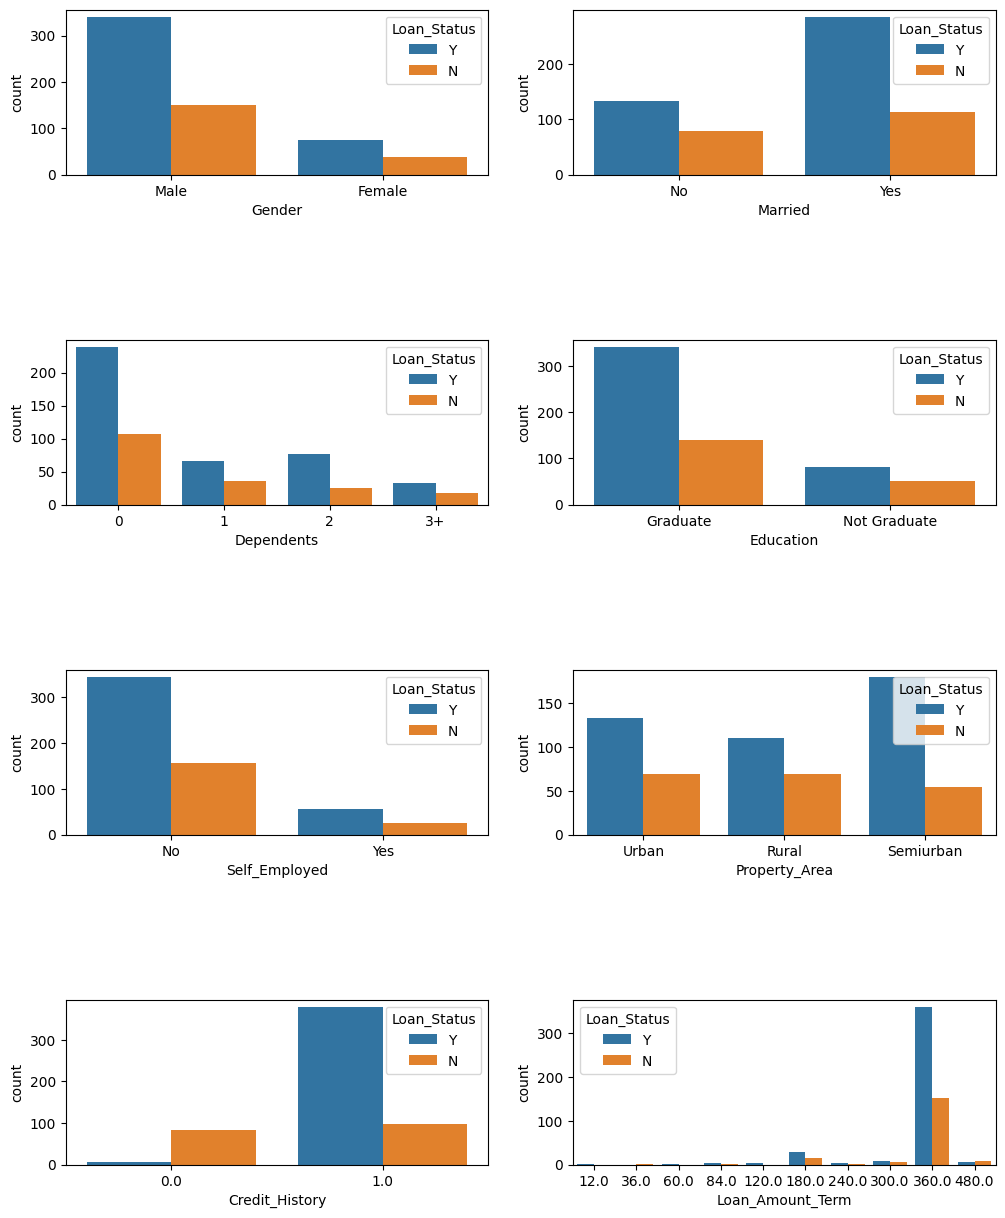

In [6]:
fig,axes = plt.subplots(4,2,figsize=(12,15))
for idx,cat_col in enumerate(categorical_columns):
    row,col = idx//2,idx%2
    sns.countplot(x=cat_col,data=df,hue='Loan_Status',ax=axes[row,col])


plt.subplots_adjust(hspace=1)

In [7]:
df.shape

(614, 13)

In [8]:
df.info

<bound method DataFrame.info of       Loan_ID  Gender Married Dependents     Education Self_Employed  \
0    LP001002    Male      No          0      Graduate            No   
1    LP001003    Male     Yes          1      Graduate            No   
2    LP001005    Male     Yes          0      Graduate           Yes   
3    LP001006    Male     Yes          0  Not Graduate            No   
4    LP001008    Male      No          0      Graduate            No   
..        ...     ...     ...        ...           ...           ...   
609  LP002978  Female      No          0      Graduate            No   
610  LP002979    Male     Yes         3+      Graduate            No   
611  LP002983    Male     Yes          1      Graduate            No   
612  LP002984    Male     Yes          2      Graduate            No   
613  LP002990  Female      No          0      Graduate           Yes   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0               5849          

Ltes see how Credit_History ffects loan_status

In [9]:
pd.crosstab(df['Credit_History'],df['Loan_Status'], margins=True)

Loan_Status,N,Y,All
Credit_History,,,
0.0,82,7,89
1.0,97,378,475
All,179,385,564


We can clearly see that applicants qith Credit_histroy 1 are more eligible to get a loan more then those who have credit_history =0 

<Axes: >

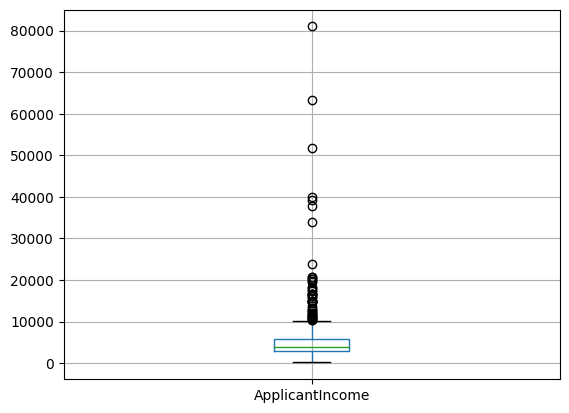

In [12]:
df.boxplot(column='ApplicantIncome')

Lots of Outliers


<Axes: >

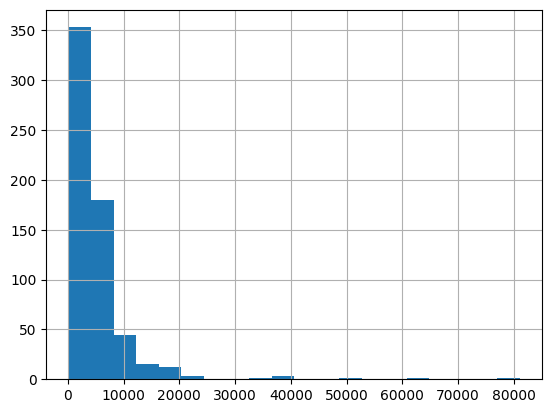

In [13]:
df['ApplicantIncome'].hist(bins=20)

<Axes: >

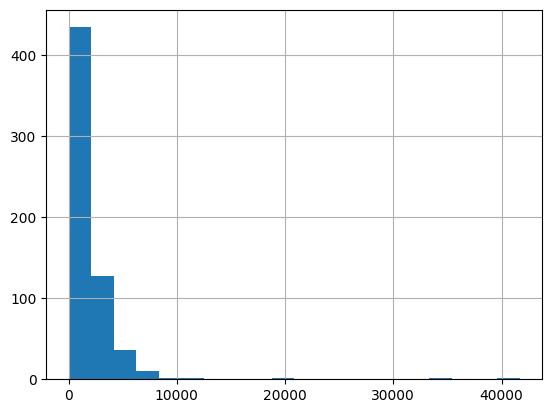

In [14]:
df['CoapplicantIncome'].hist(bins=20)

Relation Applicant Income and their education

<Axes: title={'center': 'ApplicantIncome'}, xlabel='Education'>

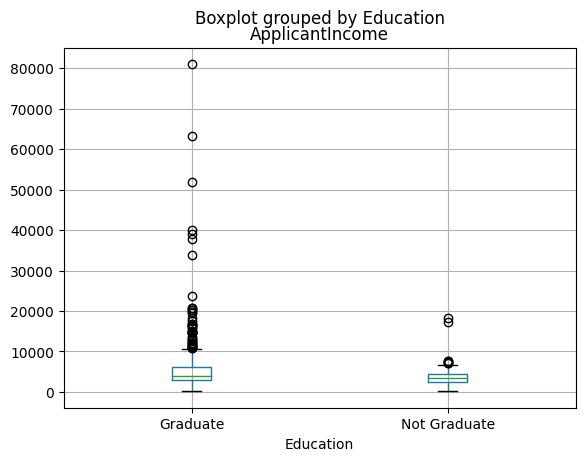

In [15]:
df.boxplot(column='ApplicantIncome',by='Education')

<Axes: >

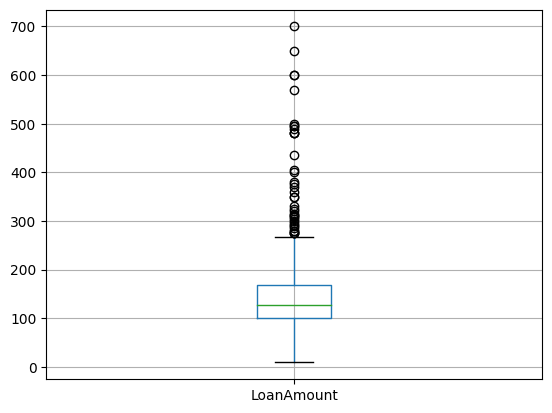

In [16]:
df.boxplot(column='LoanAmount')

most of our variables have outliers that needs to worked on

<Axes: >

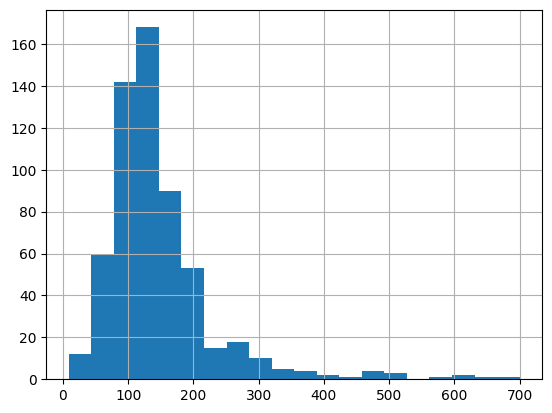

In [17]:
df['LoanAmount'].hist(bins=20)

Lets normalize the Loan Amount

<Axes: >

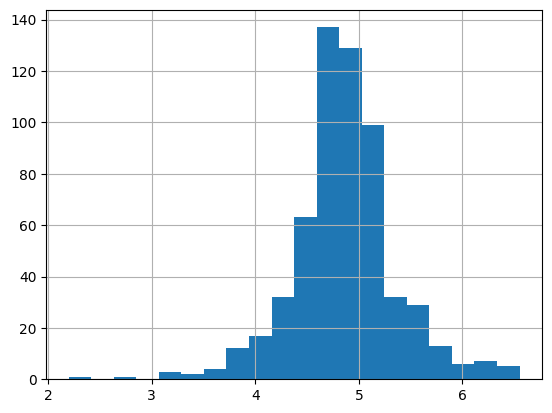

In [18]:
df['LoanAmount_log']=np.log(df['LoanAmount'])
df['LoanAmount_log'].hist(bins=20)

Data Looks more normalized after applying the log fucntion!


Finding missing values


In [19]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
LoanAmount_log       22
dtype: int64

In [20]:
for col in categorical_columns :
    df[col].fillna(df[col].mode()[0],inplace=True)

Now lets move on to non categorical(numerical) variables


       ApplicantIncome  CoapplicantIncome  LoanAmount
count       614.000000         614.000000  592.000000
mean       5403.459283        1621.245798  146.412162
std        6109.041673        2926.248369   85.587325
min         150.000000           0.000000    9.000000
25%        2877.500000           0.000000  100.000000
50%        3812.500000        1188.500000  128.000000
75%        5795.000000        2297.250000  168.000000
max       81000.000000       41667.000000  700.000000


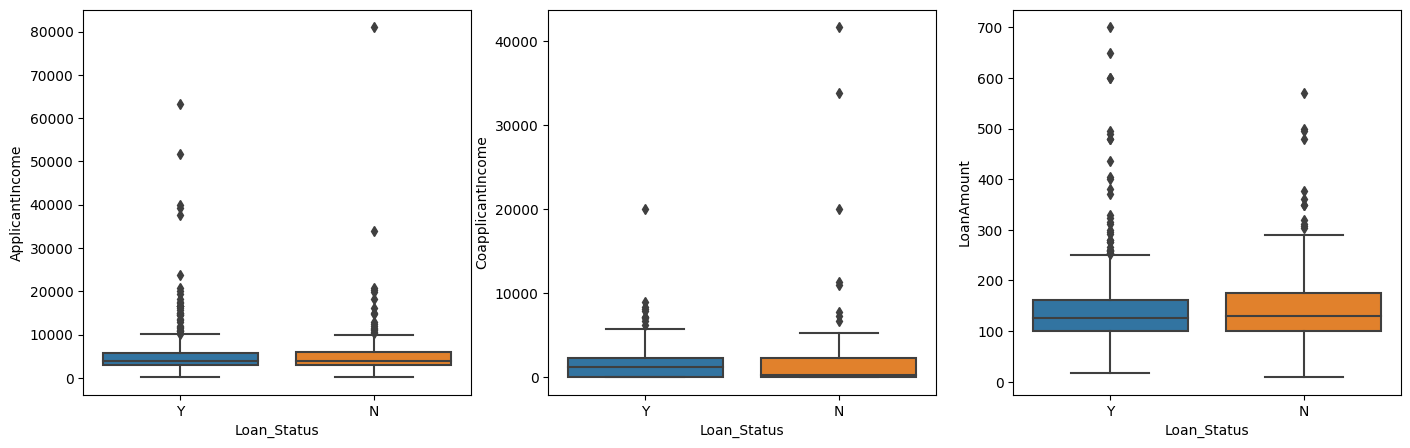

In [21]:
fig,axes = plt.subplots(1,3,figsize=(17,5))
for idx,cat_col in enumerate(numerical_columns):
    sns.boxplot(y=cat_col,data=df,x='Loan_Status',ax=axes[idx])

print(df[numerical_columns].describe())
plt.subplots_adjust(hspace=1)

Handle the null values by using the mean function


In [22]:
df['LoanAmount']=df['LoanAmount'].fillna(df['LoanAmount'].mean())

In [23]:
df['LoanAmount_log']=df['LoanAmount_log'].fillna(df['LoanAmount_log'].mean())

In [24]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
LoanAmount_log       0
dtype: int64

In [25]:
df['TotalIncome']=df['ApplicantIncome']+df['CoapplicantIncome']
df['TotalIncome_log']=np.log(df['TotalIncome'])

<Axes: >

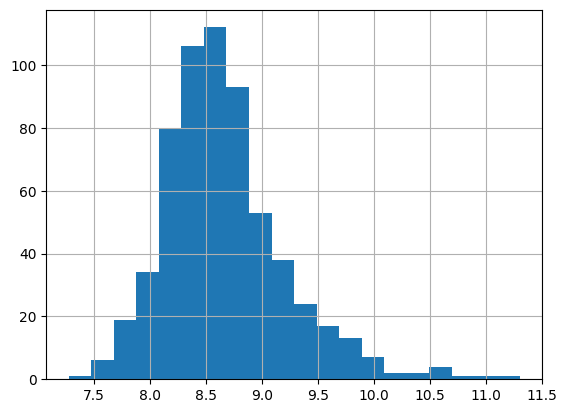

In [45]:
df['TotalIncome_log'].hist(bins=20)

Lets see how dataset looks

In [26]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,LoanAmount_log,TotalIncome,TotalIncome_log
0,LP001002,Male,No,0,Graduate,No,5849,0.0,146.412162,360.0,1.0,Urban,Y,4.857444,5849.0,8.674026
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,N,4.852030,6091.0,8.714568
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.000000,360.0,1.0,Urban,Y,4.189655,3000.0,8.006368
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,Y,4.787492,4941.0,8.505323
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,Y,4.948760,6000.0,8.699515


In [27]:
x=df.iloc[:,np.r_[1:5,9:11,13:15]].values
y=df.iloc[:,12].values

In [28]:
from sklearn .model_selection import train_test_split


x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

Converting Categorical Variables to numeric Format

In [30]:
from sklearn.preprocessing import LabelEncoder

LabelEncoder_X=LabelEncoder()

In [34]:
for i in range(0,5):
    x_train[:,i]=LabelEncoder_X.fit_transform(x_train[:,i])

In [32]:
x_train[:,7]=LabelEncoder_X.fit_transform(x_train[:,7])

In [31]:
x_train

array([['Male', 'Yes', '2', ..., 1.0, 6.173786103901937, 15114.0],
       ['Male', 'No', '2', ..., 1.0, 5.087596335232384, 10180.0],
       ['Male', 'Yes', '1', ..., 1.0, 4.852030263919617, 6091.0],
       ...,
       ['Female', 'Yes', '0', ..., 1.0, 4.919980925828125, 4786.0],
       ['Male', 'No', '0', ..., 1.0, 4.941642422609304, 6500.0],
       ['Male', 'No', '0', ..., 1.0, 4.882801922586371, 3946.0]],
      dtype=object)

In [48]:
from sklearn.preprocessing import LabelEncoder

labelEncoder_X=LabelEncoder()

In [42]:
labelEncoder_Y=LabelEncoder()
y_train=labelEncoder_Y.fit_transform(y_train)

In [46]:
y_train

array([1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0,
       1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,

In [50]:
for i in range(0,5):
    x_test[:,i]=LabelEncoder_X.fit_transform(x_test[:,i])

In [51]:
x_test[:,7]=LabelEncoder_X.fit_transform(x_test[:,7])

In [52]:
y_test=labelEncoder_Y.fit_transform(y_test)

Scale the dataset

In [54]:
from sklearn.preprocessing import StandardScaler

ss=StandardScaler()
x_train=ss.fit_transform(x_train)
x_test= ss.fit_transform(x_test)

Now Applying Decision Tree algorithm to our dataset


In [55]:
from sklearn.tree import DecisionTreeClassifier

tree_clf=DecisionTreeClassifier(criterion='entropy',random_state=0)
tree_clf.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [56]:
x_train.shape

(491, 8)

In [57]:
x_test.shape

(123, 8)

Use thi algo to predict thr values of test dataset

In [58]:
y_pred=tree_clf.predict(x_test)
y_pred

array([1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1])

lets see how well the prediction is ! 
by calculating the accuracy

In [59]:
from sklearn import metrics

print("The accuracy of Decision Tree Classifier is : ",metrics.accuracy_score(y_pred,y_test))

The accuracy of Decision Tree Classifier is :  0.6910569105691057


Naive Bayes Algo

In [60]:
from sklearn.naive_bayes import GaussianNB

nbc=GaussianNB()
nbc.fit(x_train,y_train)

GaussianNB()

In [61]:
y_pred2=nbc.predict(x_test)

In [62]:
print('The accuracy of Naive Bayes is :',metrics.accuracy_score(y_pred2,y_test))

The accuracy of Naive Bayes is : 0.7723577235772358


Import the Data

In [64]:
testdata=pd.read_csv(r"C:\users\c\Downloads\loan-test (4).csv")

In [65]:
testdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB


In [66]:
testdata.isnull().sum()

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64

In [67]:
testdata['Gender'].fillna(testdata['Gender'].mode()[0],inplace=True)
testdata['Married'].fillna(testdata['Married'].mode()[0],inplace=True)
testdata['Dependents'].fillna(testdata['Dependents'].mode()[0],inplace=True)
testdata['Self_Employed'].fillna(testdata['Self_Employed'].mode()[0],inplace=True)
testdata['Loan_Amount_Term'].fillna(testdata['Loan_Amount_Term'].mode()[0],inplace=True)
testdata['Credit_History'].fillna(testdata['Credit_History'].mode()[0],inplace=True)
testdata['LoanAmount']=testdata['LoanAmount'].fillna(testdata['LoanAmount'].mean())
# testdata['LoanAmount_log']=testdata['LoanAmount_log'].fillna(testdata['LoanAmount_log'].mean())

In [68]:
testdata.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64

<Axes: >

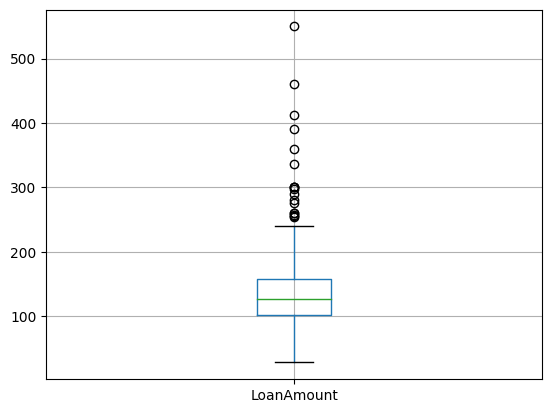

In [69]:
testdata.boxplot(column='LoanAmount')

In [70]:
testdata["LoanAmount_log"]=np.log(testdata['LoanAmount'])

In [72]:
testdata['totalIncome']=testdata['ApplicantIncome']=testdata['CoapplicantIncome']
testdata['TotalIncome_log']=np.log(testdata['totalIncome'])

In [73]:
testdata.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,LoanAmount_log,totalIncome,TotalIncome_log
0,LP001015,Male,Yes,0,Graduate,No,0,0,110.0,360.0,1.0,Urban,4.700480,0,-inf
1,LP001022,Male,Yes,1,Graduate,No,1500,1500,126.0,360.0,1.0,Urban,4.836282,1500,7.313220
2,LP001031,Male,Yes,2,Graduate,No,1800,1800,208.0,360.0,1.0,Urban,5.337538,1800,7.495542
3,LP001035,Male,Yes,2,Graduate,No,2546,2546,100.0,360.0,1.0,Urban,4.605170,2546,7.842279
4,LP001051,Male,No,0,Not Graduate,No,0,0,78.0,360.0,1.0,Urban,4.356709,0,-inf


select the data we need into variables


In [74]:
test=testdata.iloc[:,np.r_[1:5,9:11,13:15]].values

In [75]:
for i in range(0,5):
    test[:,i]=LabelEncoder_X.fit_transform(test[:,i])

In [76]:
test[:,7]=LabelEncoder_X.fit_transform(test[:,7])

In [77]:
test

array([[1, 1, 0, ..., 1.0, 0, 0],
       [1, 1, 1, ..., 1.0, 1500, 43],
       [1, 1, 2, ..., 1.0, 1800, 67],
       ...,
       [1, 0, 0, ..., 1.0, 1993, 75],
       [1, 1, 0, ..., 1.0, 2393, 101],
       [1, 0, 0, ..., 1.0, 0, 0]], dtype=object)

In [78]:
test=ss.fit_transform(test)

In [79]:
pred=nbc.predict(test)

In [80]:
pred

array([1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,